<a href="https://colab.research.google.com/github/vardhan35361/AI-Generated-voice-detection/blob/main/image_stenograpgy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Colab Cell 1: Install & imports
!pip install pycryptodome --quiet

import os
import io
import base64
import math
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files
from Crypto.Cipher import AES
from Crypto.Util.Padding import pad, unpad
from Crypto.Random import get_random_bytes
from skimage.metrics import peak_signal_noise_ratio as sk_psnr
from skimage.metrics import structural_similarity as sk_ssim
import tensorflow as tf
from tensorflow.keras import layers, models, losses, optimizers

print("Environment ready. TensorFlow version:", tf.__version__)


Environment ready. TensorFlow version: 2.19.0


In [ ]:
# Colab Cell 2: Utilities for bits/crypto/lsb/metrics
import functools

# --- Bits/Text conversion ---
def text_to_bits(s: str) -> str:
    return ''.join(format(b, '08b') for b in s.encode('utf-8'))

def bits_to_text(b: str) -> str:
    # drop incomplete bytes
    chars = [b[i:i+8] for i in range(0, len(b)-7, 8)]
    return bytes(int(x, 2) for x in chars).decode('utf-8', errors='replace')

# --- AES CBC with random IV (returns base64(iv + ciphertext)) ---
def aes_encrypt(msg: str, key: str) -> str:
    kb = key.encode('utf-8')
    if len(kb) not in (16, 24, 32):
        raise ValueError("AES key must be 16/24/32 bytes (characters).")
    iv = get_random_bytes(16)
    cipher = AES.new(kb, AES.MODE_CBC, iv)
    ct = cipher.encrypt(pad(msg.encode('utf-8'), AES.block_size))
    return base64.b64encode(iv + ct).decode('utf-8')

def aes_decrypt(b64_iv_ct: str, key: str) -> str:
    kb = key.encode('utf-8')
    if len(kb) not in (16, 24, 32):
        raise ValueError("AES key must be 16/24/32 bytes (characters).")
    raw = base64.b64decode(b64_iv_ct)
    iv = raw[:16]
    ct = raw[16:]
    cipher = AES.new(kb, AES.MODE_CBC, iv)
    pt = unpad(cipher.decrypt(ct), AES.block_size)
    return pt.decode('utf-8', errors='replace')

# --- LSB embedding (flat uint8-safe) ---
def lsb_embed(img: np.ndarray, bitstr: str, adaptive: bool=False) -> np.ndarray:
    """
    Embed bitstr into img LSBs. If adaptive True, embed in high-edge pixels first (simple heuristic).
    Assumes img dtype uint8.
    """
    h,w,c = img.shape
    capacity = img.size
    if len(bitstr) > capacity:
        raise ValueError(f"Message too long: {len(bitstr)} bits > capacity {capacity} bits")
    # flatten
    flat = img.flatten().astype(np.uint8)
    if adaptive:
        # simple edge-based ordering: compute gray edges and sort indices by descending edge magnitude
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        edges = cv2.Canny(gray, 100, 200).astype(np.uint8)
        # repeat channel indices mapping
        idx2d = np.arange(flat.size).reshape(img.shape)
        # compute a score per pixel and then expand to channels
        pixel_scores = edges.flatten()  # length h*w
        # map pixel_scores to channel indices: each pixel has c contiguous entries in flat
        # create ordering of channel indices: for pixel p, channels indices are p*c .. p*c+(c-1)
        order = np.argsort(-pixel_scores)  # pixels sorted descending
        flat_indices = np.concatenate([np.arange(p*c, p*c+c) for p in order])
        # ensure we only use first needed number of indices
        targets = flat_indices[:len(bitstr)]
    else:
        targets = np.arange(len(bitstr), dtype=np.int64)
    # embed
    for i, b in enumerate(bitstr):
        orig = int(flat[targets[i]])
        new = (orig & 0xFE) | int(b)
        flat[targets[i]] = np.uint8(new)
    return flat.reshape(img.shape)

# --- LSB extract given expected nbits (reads first nbits LSBs) ---
def lsb_extract(img: np.ndarray, nbits: int, adaptive: bool=False) -> str:
    flat = img.flatten().astype(np.uint8)
    if adaptive:
        # same ordering heuristic as embed (must match exactly)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        edges = cv2.Canny(gray, 100, 200).astype(np.uint8)
        order = np.argsort(-edges.flatten())
        flat_indices = np.concatenate([np.arange(p*3, p*3+3) for p in order])
        targets = flat_indices[:nbits]
    else:
        targets = np.arange(nbits)
    bits = ''.join(str(int(flat[int(idx)]) & 1) for idx in targets)
    return bits

# --- BER between two bitstrings (align lengths) ---
def bit_error_rate(ref_bits: str, rec_bits: str) -> float:
    L = min(len(ref_bits), len(rec_bits))
    if L == 0: return 1.0
    errors = sum(1 for i in range(L) if ref_bits[i] != rec_bits[i])
    # account for extra bits as errors
    errors += abs(len(ref_bits) - len(rec_bits))
    return errors / max(len(ref_bits), len(rec_bits))

# --- Small helper for showing images inline ---
def imshow_rgb_from_bgr(bgr, title=''):
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(4,4)); plt.imshow(rgb); plt.title(title); plt.axis('off'); plt.show()


In [ ]:
# Colab Cell 3: Upload + user inputs
print("📂 Upload a cover image (PNG/JPG). Recommended size: >=256x256.")
uploaded = files.upload()
fname = list(uploaded.keys())[0]
print("Loaded:", fname)

# read and optionally resize to 256x256
img_bgr = cv2.imdecode(np.frombuffer(uploaded[fname], np.uint8), cv2.IMREAD_COLOR)
img_bgr = cv2.resize(img_bgr, (256,256))
print("Image shape:", img_bgr.shape, "| dtype:", img_bgr.dtype)
imshow_rgb_from_bgr(img_bgr, "Cover Image")

secret = input("💬 Enter the secret message you want to hide: ")
key = input("🔑 Enter AES key (16/24/32 characters for AES-128/192/256): ")
if len(key.encode('utf-8')) not in (16,24,32):
    raise ValueError("Key must be 16/24/32 bytes (characters).")

ADAPTIVE_EMBED = input("Adaptive edge-aware embedding? (y/N): ").strip().lower().startswith('y')
print("Adaptive embedding:", ADAPTIVE_EMBED)


📂 Upload a cover image (PNG/JPG). Recommended size: >=256x256.


🔒 Encrypted (base64 iv+ct): 1wy8OEErbonJv4Iy7WjZ5wnMDKQL2e84UzHzfdxE+Kg=
✅ Stego image written: stego_output.png


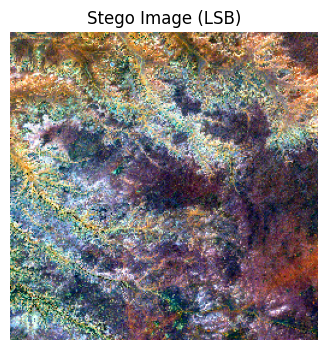

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Colab Cell 4: Encrypt, embed, save stego
# Encrypt using AES-CBC with random IV and base64 the iv+ct
enc = aes_encrypt(secret, key)
print("🔒 Encrypted (base64 iv+ct):", enc)

# Convert encrypted base64 string to bits
# enc_bits = text_to_bits(enc) # Moved to Cell 7
# delimiter = '1111111111111110'  # 16 ones + 0 marker # Moved to Cell 7
# bits_with_marker = enc_bits + delimiter # Moved to Cell 7

# Embed
stego = lsb_embed(img_bgr.copy(), text_to_bits(enc) + '1111111111111110', adaptive=ADAPTIVE_EMBED)
outname = "stego_output.png"
cv2.imwrite(outname, stego)
print("✅ Stego image written:", outname)
imshow_rgb_from_bgr(stego, "Stego Image (LSB)")
# allow download
files.download(outname)

In [ ]:
# Colab Cell 5: Build & train a simple convolutional autoencoder on the stego image
# Note: For real robustness, train on many stego images. This demo trains on the single stego image.
input_shape = (256,256,3)
latent_dim = 512

def build_autoencoder(input_shape, latent_dim=512):
    inp = layers.Input(shape=input_shape)
    x = layers.Normalization()(inp)
    # Encoder
    x = layers.Conv2D(32,3,activation='relu',padding='same',strides=2)(x) # 128
    x = layers.Conv2D(64,3,activation='relu',padding='same',strides=2)(x) # 64
    x = layers.Conv2D(128,3,activation='relu',padding='same',strides=2)(x) #32
    x = layers.Flatten()(x)
    x = layers.Dense(latent_dim, activation='relu')(x)
    # Decoder
    x = layers.Dense(32*32*128, activation='relu')(x)
    x = layers.Reshape((32,32,128))(x)
    x = layers.Conv2DTranspose(128,3,activation='relu',padding='same',strides=2)(x) # 64
    x = layers.Conv2DTranspose(64,3,activation='relu',padding='same',strides=2)(x) # 128
    x = layers.Conv2DTranspose(32,3,activation='relu',padding='same',strides=2)(x) # 256
    out = layers.Conv2D(3,3,activation='sigmoid',padding='same')(x)
    model = models.Model(inp, out)
    model.compile(optimizer=optimizers.Adam(1e-3), loss=losses.MeanSquaredError())
    return model

ae = build_autoencoder(input_shape, latent_dim)
ae.summary()

# Prepare training data (single image) normalized
X = np.expand_dims(stego.astype('float32') / 255.0, axis=0)

EPOCHS = 30  # increase for better results
history = ae.fit(X, X, epochs=EPOCHS, verbose=1)
print("Autoencoder training complete.")


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_1 (Normalization) │ (None, 256, 256, 3)    │             7 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    67,109,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 131072)         │    67,239,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 64, 64, 128)    │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 128, 128, 64)   │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 256, 256, 32)   │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 256, 256, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,683,274 (513.78 MB)

 Trainable params: 134,683,267 (513.78 MB)

 Non-trainable params: 7 (32.00 B)

Epoch 1/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - loss: 0.0547
Epoch 2/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0546
Epoch 3/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.0545
Epoch 4/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.0544
Epoch 5/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.0543
Epoch 6/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.0542
Epoch 7/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0541
Epoch 8/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0539
Epoch 9/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0537
Epoch 10/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.0535
Epoch 11/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.0533
Epoch 12/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.0530
Epoch 13/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.0526
Epoch 14/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0518
Epoch 15/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0494
Epoch 16/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.0425
E

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step


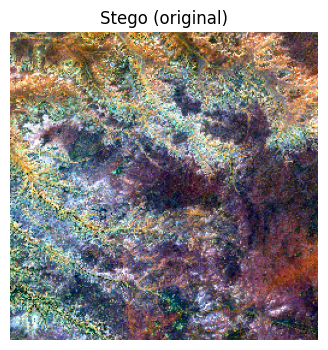

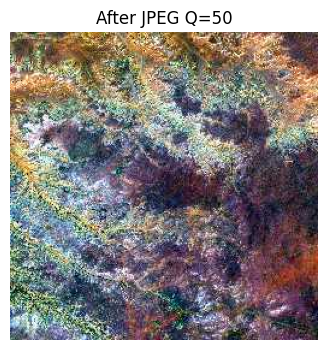

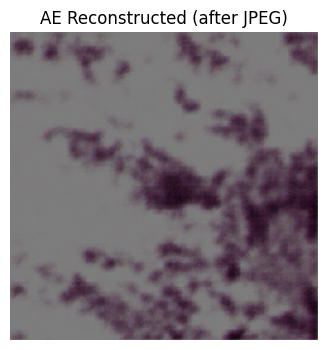

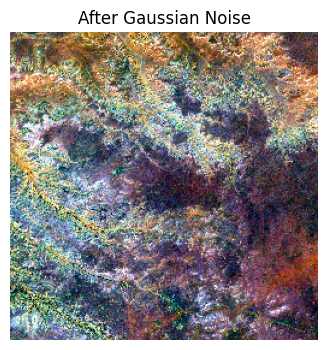

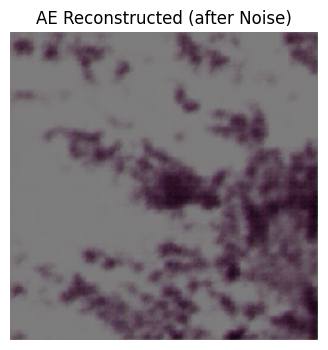

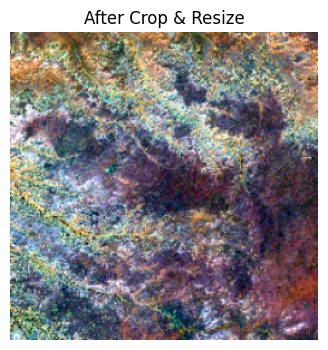

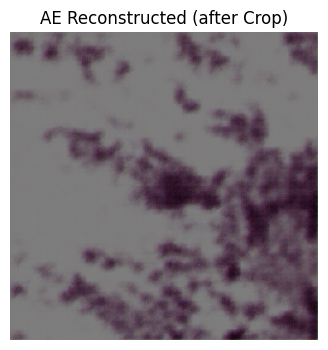

In [ ]:
# Colab Cell 6: Attack simulations and AE reconstruction
# Read the saved stego as uint8
stego_uint8 = cv2.imread(outname)

# 1) JPEG compression attack
encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), 50]
_, encimg = cv2.imencode('.jpg', stego_uint8, encode_param)
decimg_jpeg = cv2.imdecode(encimg, cv2.IMREAD_COLOR)

# 2) Gaussian noise
noise = (np.random.normal(0, 10, stego_uint8.shape)).astype(np.int16)
decimg_noise = np.clip(stego_uint8.astype(np.int16) + noise, 0, 255).astype(np.uint8)

# 3) Crop & resize (simulate cropping)
h,w,_ = stego_uint8.shape
crop = stego_uint8[16:h-16,16:w-16]
decimg_crop = cv2.resize(crop, (w,h))

# Reconstruct via AE: normalize inputs and predict
def ae_reconstruct(img):
    x = np.expand_dims(img.astype('float32')/255.0, axis=0)
    rec = ae.predict(x)[0]
    rec_uint8 = (rec*255.0).astype(np.uint8)
    return rec_uint8

rec_clean = ae_reconstruct(stego_uint8)
rec_jpeg = ae_reconstruct(decimg_jpeg)
rec_noise = ae_reconstruct(decimg_noise)
rec_crop = ae_reconstruct(decimg_crop)

# Display
imshow_rgb_from_bgr(stego_uint8, "Stego (original)")
imshow_rgb_from_bgr(decimg_jpeg, "After JPEG Q=50")
imshow_rgb_from_bgr(rec_jpeg, "AE Reconstructed (after JPEG)")
imshow_rgb_from_bgr(decimg_noise, "After Gaussian Noise")
imshow_rgb_from_bgr(rec_noise, "AE Reconstructed (after Noise)")
imshow_rgb_from_bgr(decimg_crop, "After Crop & Resize")
imshow_rgb_from_bgr(rec_crop, "AE Reconstructed (after Crop)")

In [ ]:
# stego_uint8 = cv2.imread(outname) # Removed redundant definition

# Redefine variables from Cell 4
delimiter = '1111111111111110'  # 16 ones + 0 marker
enc_bits = text_to_bits(enc)
bits_with_marker = enc_bits + delimiter

# helper to perform extraction then decrypt
def extract_and_decrypt(img_uint8, total_capacity, adaptive=False):
    # Extract bits up to the capacity or until delimiter is found
    bits = lsb_extract(img_uint8, total_capacity, adaptive=adaptive)

    # find delimiter to determine message length
    if delimiter in bits:
        bits_msg = bits.split(delimiter)[0]
    else:
        # If delimiter not found, assume the entire extracted bits (up to capacity) are the message
        bits_msg = bits

    # Convert extracted bits back to the original base64 encoded string
    # We need to ensure the bit string is a multiple of 8 before converting to bytes
    # to avoid issues with base64 decoding later.
    bits_msg_padded = bits_msg + '0' * ((8 - len(bits_msg) % 8) % 8)
    byte_array = bytearray()
    for i in range(0, len(bits_msg_padded), 8):
        byte_array.append(int(bits_msg_padded[i:i+8], 2))

    # The extracted bits represent the original base64 encoded string.
    # We need to decode this base64 string to get the raw encrypted data.
    try:
        extracted_enc_bytes = base64.b64decode(bytes(byte_array))
        extracted_enc = base64.b64encode(extracted_enc_bytes).decode('ascii', errors='ignore') # Keep the base64 string for display

        # try decrypt
        # AES decryption requires padding, which is handled by aes_decrypt's unpad
        decrypted = aes_decrypt(extracted_enc, key)
    except Exception as e:
        decrypted = f"[decryption failed] {e}"
        extracted_enc = "[decoding failed]" # Indicate if base64 decoding failed

    return bits_msg, extracted_enc, decrypted

# expected nbits - use the full capacity for extraction now
# total_capacity = img_bgr.size # Use the length of the original embedded bits with marker
total_capacity = len(bits_with_marker)


# Do extraction on several images
cases = {
    'stego_saved': stego_uint8,
    'rec_clean': rec_clean,
    'decimg_jpeg': decimg_jpeg,
    'rec_jpeg': rec_jpeg,
    'decimg_noise': decimg_noise,
    'rec_noise': rec_noise,
    'decimg_crop': decimg_crop,
    'rec_crop': rec_crop
}

results = {}
for name, img in cases.items():
    bits_msg, extracted_enc, decrypted = extract_and_decrypt(img, total_capacity, adaptive=ADAPTIVE_EMBED)
    # Calculate BER against the original embedded bits (with the delimiter)
    # We should compare the extracted bits up to the length of the original embedded bits.
    extracted_bits_for_ber = bits_msg[:len(bits_with_marker)]
    ber = bit_error_rate(bits_with_marker, extracted_bits_for_ber)

    psnr_cover_stego = sk_psnr(img_bgr, stego_uint8, data_range=255) # This should be PSNR between cover and the *current* image
    psnr_cover_current = sk_psnr(img_bgr, img, data_range=255)

    # compute SSIM between cover and this image (converted to RGB)
    ssim_val = sk_ssim(cv2.cvtColor(img_bgr,cv2.COLOR_BGR2RGB),
                       cv2.cvtColor(img,cv2.COLOR_BGR2RGB),
                       channel_axis=-1, data_range=255)
    results[name] = dict(bits_len=len(bits_msg), ber=ber, extracted_enc=extracted_enc, decrypted=decrypted, ssim=ssim_val, psnr=psnr_cover_current)


# Print summary
for k,v in results.items():
    print(f"--- {k} ---")
    print(f"BER: {v['ber']:.4f}  | Extracted bits: {v['bits_len']} | Decrypted: {v['decrypted']}")
    print(f"PSNR(cover->this): {v['psnr']:.2f} dB | SSIM(cover->this): {v['ssim']:.4f}")
    print()

--- stego_saved ---
BER: 0.4563  | Extracted bytes: 44 | Decrypted: [decryption failed] Data must be padded to 16 byte boundary in CBC mode
PSNR(cover->this): 78.59 dB | SSIM(cover->this): 1.0000

--- rec_clean ---
BER: 0.9977  | Extracted bytes: 9466 | Decrypted: [decryption failed] Data must be padded to 16 byte boundary in CBC mode
PSNR(cover->this): 78.59 dB | SSIM(cover->this): 0.1568

--- decimg_jpeg ---
BER: 0.9823  | Extracted bytes: 1207 | Decrypted: [decryption failed] Data must be padded to 16 byte boundary in CBC mode
PSNR(cover->this): 78.59 dB | SSIM(cover->this): 0.7585

--- rec_jpeg ---
BER: 0.9988  | Extracted bytes: 16311 | Decrypted: [decryption failed] Data must be padded to 16 byte boundary in CBC mode
PSNR(cover->this): 78.59 dB | SSIM(cover->this): 0.1564

--- decimg_noise ---
BER: 0.9973  | Extracted bytes: 8560 | Decrypted: [decryption failed] Padding is incorrect.
PSNR(cover->this): 78.59 dB | SSIM(cover->this): 0.9605

--- rec_noise ---
BER: 0.9922  | Extract

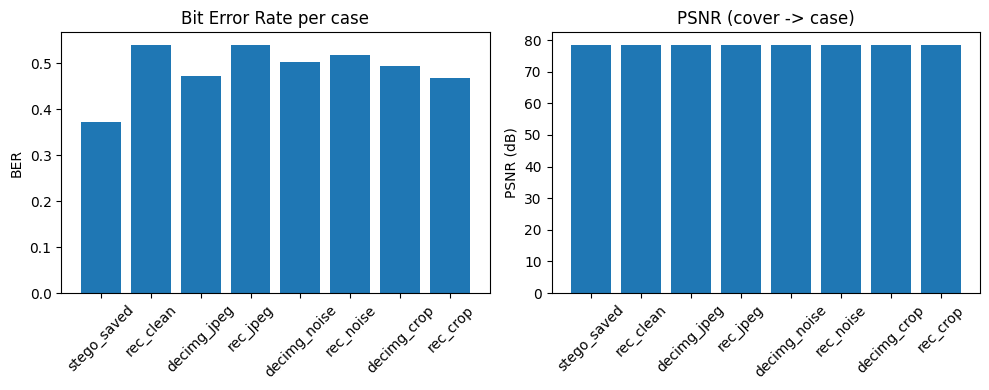

Saved reconstructions: rec_jpeg.png, rec_noise.png, rec_crop.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Colab Cell 8: Plot BER & PSNR summary
names = list(results.keys())
bers = [results[n]['ber'] for n in names]
psnrs = [results[n]['psnr'] for n in names]
ssims = [results[n]['ssim'] for n in names]

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.bar(names, bers)
plt.xticks(rotation=45); plt.ylabel('BER'); plt.title('Bit Error Rate per case')

plt.subplot(1,2,2)
plt.bar(names, psnrs)
plt.xticks(rotation=45); plt.ylabel('PSNR (dB)'); plt.title('PSNR (cover -> case)')

plt.tight_layout()
plt.show()

# Save reconstructed images for inspection
cv2.imwrite("rec_jpeg.png", rec_jpeg)
cv2.imwrite("rec_noise.png", rec_noise)
cv2.imwrite("rec_crop.png", rec_crop)
print("Saved reconstructions: rec_jpeg.png, rec_noise.png, rec_crop.png")
files.download("rec_jpeg.png")


In [ ]:
# Colab Cell 9: Tips and quick switches
print("Tips:")
print("- To improve robustness, increase AE training epochs and train on a dataset of stego images (not a single image).")
print("- To use AES-256 provide 32-character key.")
print("- For stronger encryption and integrity, consider encrypt-then-MAC (e.g., HMAC) or use authenticated encryption (AES-GCM).")
print("- To implement GAN-based or end-to-end deep steganography, replace the LSB embed/extract with learned embedding layers.")


Tips:
- To improve robustness, increase AE training epochs and train on a dataset of stego images (not a single image).
- To use AES-256 provide 32-character key.
- For stronger encryption and integrity, consider encrypt-then-MAC (e.g., HMAC) or use authenticated encryption (AES-GCM).
- To implement GAN-based or end-to-end deep steganography, replace the LSB embed/extract with learned embedding layers.
